In [ ]:
# !pip install torch torchvision torchaudio transformers accelerate bitsandbytes --quiet
# !pip install -U bitsandbytes

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
import os
import random
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings("ignore")

from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

In [2]:
drive.mount('/content/drive')

drive_folder = "/content/drive/MyDrive/Aireen Y4S1/WIE3007 DATA MINING AND WAREHOUSING/Group Assignment 15%"

Mounted at /content/drive


In [3]:
# Setup huggingface token
from google.colab import userdata
HUGGINGFACE_TOKEN = userdata.get("HF_TOKEN")

from huggingface_hub import login
login(token=HUGGINGFACE_TOKEN)

In [4]:
preprocessed_df = pd.read_csv(os.path.join(drive_folder, "preprocessed_data.csv"))

# Feature Engineering

In [5]:
preprocessed_df.drop(columns=['Sentiment_Score'], inplace=True)
preprocessed_df.drop(columns=['LoanPurposeDescription'], inplace=True)

In [6]:
preprocessed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 47 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   CustomerID                           1000 non-null   int64  
 1   Age                                  1000 non-null   int64  
 2   Education                            1000 non-null   float64
 3   EmploymentLengthYears                1000 non-null   int64  
 4   MonthlyIncome                        1000 non-null   float64
 5   Dependents                           1000 non-null   int64  
 6   CreditScore                          1000 non-null   int64  
 7   ExistingLoans                        1000 non-null   int64  
 8   MonthlyDebt                          1000 non-null   float64
 9   YearsWithBank                        1000 non-null   int64  
 10  HasSavingsAccount                    1000 non-null   int64  
 11  HasCheckingAccount             

In [7]:
X = preprocessed_df.drop("LoanDefault", axis=1)
y = preprocessed_df["LoanDefault"]

numerical_cols = ["Age", "EmploymentLengthYears", "MonthlyIncome", "Dependents", "CreditScore", "ExistingLoans", "MonthlyDebt", "YearsWithBank", "LoanAmount", "LoanTermMonths", "InterestRate" ]

In [8]:
X_standardized = X.copy()

standard_scaler = StandardScaler()

X_standardized[numerical_cols] = standard_scaler.fit_transform(X[numerical_cols])

print("Standardization using StandardScaler")
print(f"Shape: {X_standardized.shape}")

# See before and after
print("\nBefore Standardization:")
print(X[numerical_cols].head(10))
print("\nAfter Standardization:")
print(X_standardized[numerical_cols].head(10))

Standardization using StandardScaler
Shape: (1000, 46)

Before Standardization:
   Age  EmploymentLengthYears  MonthlyIncome  Dependents  CreditScore  \
0   59                     11    9067.159786           2          770   
1   51                     24    5068.058742           1          698   
2   24                      0    2557.541824           0          480   
3   25                      0    7535.097299           0          774   
4   25                      5    4798.465251           2          590   
5   18                      0    2715.312586           0          576   
6   26                      2    8468.695614           2          648   
7   23                      0    2079.184097           3          581   
8   46                      8    9386.927084           0          688   
9   39                     13    9241.197498           2          655   

   ExistingLoans  MonthlyDebt  YearsWithBank    LoanAmount  LoanTermMonths  \
0              3  1583.065500         

# Model Development

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_standardized, y, test_size=0.2, random_state=42, stratify=y)

## Overfitting Model

In [10]:
# Train overfitting model
knn_overfit = KNeighborsClassifier(n_neighbors=1)
knn_overfit.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [12]:
# Evaluate overfitting model
y_train_pred_overfit = knn_overfit.predict(X_train)
y_test_pred_overfit = knn_overfit.predict(X_test)

train_accuracy_overfit = accuracy_score(y_train, y_train_pred_overfit)
test_accuracy_overfit = accuracy_score(y_test, y_test_pred_overfit)

print(f"OVERFITTING MODEL:")
print(f"Train Accuracy: {train_accuracy_overfit:.4f}")
print(f"Test Accuracy: {test_accuracy_overfit:.4f}")
print(f"Overfitting Gap: {(train_accuracy_overfit - test_accuracy_overfit):.4f}")

print("\nClassification Report (Training):")
print(classification_report(y_train, y_train_pred_overfit))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_overfit))

OVERFITTING MODEL:
Train Accuracy: 1.0000
Test Accuracy: 0.6200
Overfitting Gap: 0.3800

Classification Report (Training):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      1.00      1.00       400

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.64      0.54      0.59       100
           1       0.60      0.70      0.65       100

    accuracy                           0.62       200
   macro avg       0.62      0.62      0.62       200
weighted avg       0.62      0.62      0.62       200



## Optimal Model

In [13]:
# Hyperparameter tuning

# Define parameter grid
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31, 51],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

# Perform grid search with cross validation
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Print result of grid search
print(f"✓ Grid Search completed")
print(f"\nBest Parameters: \n{grid_search.best_params_}")
print(f"\nBest Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
✓ Grid Search completed

Best Parameters: 
{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}

Best Score: 0.6725


In [14]:
# Train optimal model
knn_optimal = grid_search.best_estimator_

OPTIMAL MODEL:
Train Accuracy: 1.0000
Test Accuracy: 0.7100
Overfitting Gap: 0.2900

Classification Report (Training):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      1.00      1.00       400

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.73      0.67      0.70       100
           1       0.69      0.75      0.72       100

    accuracy                           0.71       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.71      0.71      0.71       200


Confusion Matrix:


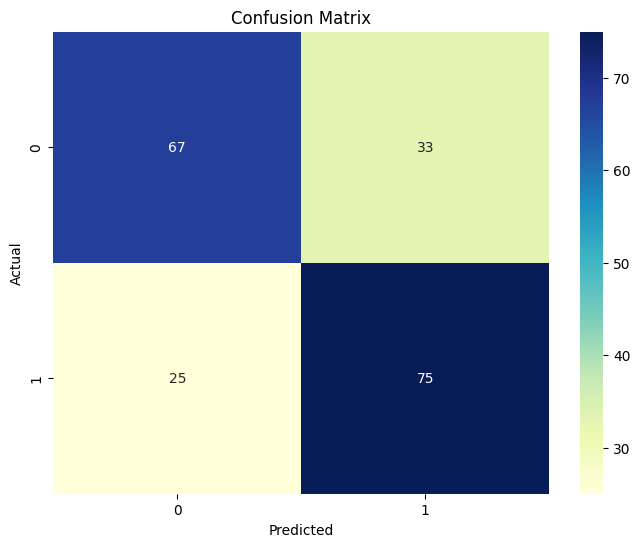

In [22]:
# Evaluate optimal model
y_train_pred_optimal = knn_optimal.predict(X_train)
y_test_pred_optimal = knn_optimal.predict(X_test)

train_accuracy_optimal = accuracy_score(y_train, y_train_pred_optimal)
test_accuracy_optimal = accuracy_score(y_test, y_test_pred_optimal)

print(f"OPTIMAL MODEL:")
print(f"Train Accuracy: {train_accuracy_optimal:.4f}")
print(f"Test Accuracy: {test_accuracy_optimal:.4f}")
print(f"Overfitting Gap: {(train_accuracy_optimal - test_accuracy_optimal):.4f}")

print("\nClassification Report (Training):")
print(classification_report(y_train, y_train_pred_optimal))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_optimal))

cm = confusion_matrix(y_test, y_test_pred_optimal)
print("\nConfusion Matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model Evaluation and Interpretation